<span style="color:gray; font-size:smaller;">Written by Salil Deshpande</span>

This tutorial describes how to perform some common downstream analyses given a MotifCompendium object. This tutorial also covers some additional functionality available as a part of the MotifCompendium package.

Let's get started!

We will begin by importing the packages that we will need.

In [1]:
import gdown
import h5py
import numpy as np

import MotifCompendium
import MotifCompendium.utils.analysis as utils_analysis
import MotifCompendium.utils.loader as utils_loader
import MotifCompendium.utils.motif as utils_motif
import MotifCompendium.utils.similarity as utils_similarity

This tutorial will be written as if we had access to a 12GB GPU. If you want to run this tutorial yourself but do not have access to a GPU then set `use_gpu=False` and do not set the `max_chunk` parameter.

In [2]:
MotifCompendium.set_compute_options(max_cpus=4, use_gpu=True, max_chunk=1152, progress_bar=True)

We will also download all the data that we will need for this tutorial.

In [3]:
tutorial_mc_id = "1XQ7pWbEeP2RKEg5d5jJ1JOjotXXPFaeL"
tutorial_mc_url = f"https://drive.google.com/uc?id={tutorial_mc_id}"
tutorial_mc_file = "tutorial_data/tutorial_motif_compendium.mc"
gdown.download(tutorial_mc_url, tutorial_mc_file, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XQ7pWbEeP2RKEg5d5jJ1JOjotXXPFaeL
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/tutorial_motif_compendium.mc
100%|██████████| 1.30M/1.30M [00:00<00:00, 45.9MB/s]


'tutorial_data/tutorial_motif_compendium.mc'

# Part 1 - Exporting a MotifCompendium object

In [4]:
mc = MotifCompendium.load("tutorial_data/tutorial_motif_compendium.mc")
mc

,name,num_seqlets,model,posneg,avg_dist_from_summit,cluster,annotation
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,15.721553,0,CTCF#1_0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,33.662853,8,NFI#1_8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,33.419699,11,HD:MEIS-TGIF_11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,36.965818,12,GATA#1_12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,42.597554,13,ETS:ELF-ETV#1_13
...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,37.803475,9,BZIP:FOSL-JUND#1_9
84,endothelial-pos.pattern_6,2977,endothelial,pos,35.074236,10,NFY_10
85,endothelial-pos.pattern_7,2358,endothelial,pos,37.488550,4,BZIP:ATF-CREB#1_4
86,endothelial-pos.pattern_8,2115,endothelial,pos,51.907329,76,ETS:ELF-SPIB#1_76


After having clustered and analyzed motifs with MotifCompendium, one of the most common next steps to take is to export your motifs to [FiNeMo](https://github.com/austintwang/finemo_gpu) for motif hit calling. FiNeMo expects motifs to be in a .h5 file with the same structure as Modisco outputs. The analysis submodule provides utilities for exporting motifs in a format that is compatible with FiNeMo. The `export_compendium_modisco()` function takes in a MotifCompendium that you want to export, a column that contains the names for each motif, and a path to save the exported motifs to. In the output file, each motif in the calling MotifCompendium will be its own group.

In [5]:
utils_analysis.export_compendium_modisco(mc, "name", "tutorial_outputs/tutorial_motif_compendium_modisco.h5")

Now, let's inspect the structure of the resulting .h5 file to make sure it contains what we expect.

In [6]:
def check_structure(file_loc):
    with h5py.File(file_loc, 'r') as f:
        for k in f:
            print(f"--- {k} ---")
            inspect_level(f[k], 1)

def inspect_level(g, l):
    prefix = "    "*(l-1)
    next_groups = []
    for z in g:
        if isinstance(g[z], h5py.Dataset):
            print(prefix + f"- {z} [Dataset]: {g[z][()].shape}")
        else:
            next_groups.append(z)
    for z in next_groups:
        print(prefix + f"* {z} [Group]: {len(list(g[z]))}")
        inspect_level(g[z], l+1)

In [7]:
check_structure("tutorial_outputs/tutorial_motif_compendium_modisco.h5")

--- neg_patterns ---
* cardiomyocyte-neg.pattern_0_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-neg.pattern_1_1 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-neg.pattern_2_2 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-neg.pattern_3_3 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
--- pos_patterns ---
* cardiomyocyte-pos.pattern_0_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_10_2 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_11_3 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_12_4 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_13_5 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_14_6 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_15_7 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* cardiomyocyte-pos.pattern_16_8 [Group

The exported file has the structure and content that we expect.

The `export_compendium_modicso()` function also has an optional argument called `inverse_ic`. When set to `True`, the motifs have information-content scaling undone. By default, `inverse_ic` is `False`, and **you should only set it to `True` if your motifs were IC-scaled previously**, which is done by default when loading from Modisco for PFMs with MotifCompendium. **Even then, however, it is not necessary undo IC-scaling**. If you would like to keep your motifs IC-scaled and run FiNeMo, though, you may need to adjust the `finemo call-hits` trimming threshold down from 0.3. The trimming threshold of `-t 0.15` seems to work well for IC-scaled motifs, but you may have to tune that number depending on your dataset.

In [8]:
utils_analysis.export_compendium_modisco(mc, "name", "tutorial_outputs/tutorial_motif_compendium_modisco_ic_inverted.h5", inverse_ic=True)

There is a similar function, `export_compendium_clustered_modisco()` that can take a MotifCompendium that has been clustered and export each cluster as a pattern. `export_compendium_clustered_modisco()` takes in a MotifCompendium that you want to export, a column that contains per-motif cluster assignments, and a path to save the exported motifs to. Below, we can export the the clusters as defined by the `annotation` column.

In [9]:
utils_analysis.export_compendium_clustered_modisco(mc, "annotation", "tutorial_outputs/tutorial_motif_compendium_clusters_modisco.h5")

computing similarities on GPU...: 100%|██████████| 1/1 [00:05<00:00,  5.18s/it]


Now, let's inspect the structure of the resulting .h5 file to make sure it contains what we expect. It should have one pattern for each cluster not just one pattern for each motif.

In [10]:
check_structure("tutorial_outputs/tutorial_motif_compendium_clusters_modisco.h5")

--- neg_patterns ---
* NFYrepressive_41_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* YY1-2repressive_42_1 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* ZBT7A.H13CORE.0.P.B_43_2 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* ZEB-SNAI_44_3 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
--- pos_patterns ---
* BANP-ZBTB33_7_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:ATF-CREB#1_16_1 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:ATF-CREB#1_40_3 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:ATF-CREB#1_4_2 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:ATF-CREB#1_57_4 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:ATF-CREB_ETS:ELF-ETV_54_5 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:CEBP#1_18_6 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:FOSL-JUND#1_30_7 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* BZIP:FOSL-JUND#1_63_8 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)

And indeed, it has the correct structure with each pattern being a cluster. And, the patterns are named by the anntations!

The patterns that are exported are an average of all motifs in the cluster. However, if you would like, you can export a weighted average of motifs in a cluster. For example, one may want to weigh each motif by its number of constituent seqlets. To do so, set the `weight_col` argument to the name of any column in the MotifCompendium, the value of which will be interpreted as a numerical weighting on each motif.

In [11]:
utils_analysis.export_compendium_clustered_modisco(mc, "cluster", "tutorial_outputs/tutorial_motif_compendium_clusters_modisco_weighted.h5", weight_col="num_seqlets")

computing similarities on GPU...: 100%|██████████| 1/1 [00:00<00:00, 109.79it/s]


Just as with `export_compendium_modisco()`, you can perform inverse IC-scaling by setting `inverse_ic=True`. As before, it is `False` by default.

In [12]:
utils_analysis.export_compendium_clustered_modisco(mc, "cluster", "tutorial_outputs/tutorial_motif_compendium_clusters_modisco_ic_inverted.h5", inverse_ic=True)

computing similarities on GPU...: 100%|██████████| 1/1 [00:00<00:00, 126.79it/s]


Another feature of `export_compendium_clustered_modisco()` is that you can export the individual motifs as subpatterns of the cluster patterns. To do so, just set `export_subpatterns=True`. 

In [13]:
utils_analysis.export_compendium_clustered_modisco(mc, "cluster", "tutorial_outputs/tutorial_motif_compendium_clusters_modisco_subpatterns.h5", export_subpatterns=True)

computing similarities on GPU...: 100%|██████████| 1/1 [00:00<00:00, 114.80it/s]


When we inspect the structure of the resulting .h5 file, we will see that each cluster pattern now has subpatterns inside, corresponding to the motifs in that cluster.

In [14]:
check_structure("tutorial_outputs/tutorial_motif_compendium_clusters_modisco_subpatterns.h5")

--- neg_patterns ---
* 41_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 42_1 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 43_2 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 44_3 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
--- pos_patterns ---
* 0_0 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 10_10 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 11_11 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 12_12 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 13_13 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 14_14 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 15_15 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 16_16 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 17_17 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 18_18 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 19_19 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 1_1 [Group]: 1
    - contrib_scores [Dataset]: (30, 4)
* 20_20 [Group]: 1
   

You can also export your MotifCompendium in a MEME file format with the `export_compendium_meme()` function in the analysis submodule. The `export_compendium_meme()` function takes in a MotifCompendium that you want to export, a column that contains the names for each motif, and a path to save the exported motifs to. In the output file, each motif will be its own entry, and it will have been exported as a 4 channel motif.

In [15]:
utils_analysis.export_compendium_meme(mc, "name", "tutorial_outputs/tutorial_motif_compendium_meme.meme")

And we can use the `load_pfm()` function from the loader submodule to check that the resulting MEME file contains all the motifs that it should. **When they are exported by MEME, the motifs have their flanks with 0 importance trimmed; and, because MEME is a text format, the floating point motif values are truncated. The result of this is that the motifs do not exactly line up with the original motifs when exported by MEME.**

In [16]:
# Load motifs
motifs, motif_names = utils_loader.load_pfm("tutorial_outputs/tutorial_motif_compendium_meme.meme")
print(motifs.shape)
print(motif_names)

(88, 30, 4)
['cardiomyocyte-pos.pattern_0', 'cardiomyocyte-pos.pattern_1', 'cardiomyocyte-pos.pattern_10', 'cardiomyocyte-pos.pattern_11', 'cardiomyocyte-pos.pattern_12', 'cardiomyocyte-pos.pattern_13', 'cardiomyocyte-pos.pattern_14', 'cardiomyocyte-pos.pattern_15', 'cardiomyocyte-pos.pattern_16', 'cardiomyocyte-pos.pattern_17', 'cardiomyocyte-pos.pattern_18', 'cardiomyocyte-pos.pattern_19', 'cardiomyocyte-pos.pattern_2', 'cardiomyocyte-pos.pattern_20', 'cardiomyocyte-pos.pattern_21', 'cardiomyocyte-pos.pattern_22', 'cardiomyocyte-pos.pattern_23', 'cardiomyocyte-pos.pattern_24', 'cardiomyocyte-pos.pattern_25', 'cardiomyocyte-pos.pattern_26', 'cardiomyocyte-pos.pattern_27', 'cardiomyocyte-pos.pattern_28', 'cardiomyocyte-pos.pattern_29', 'cardiomyocyte-pos.pattern_3', 'cardiomyocyte-pos.pattern_30', 'cardiomyocyte-pos.pattern_31', 'cardiomyocyte-pos.pattern_32', 'cardiomyocyte-pos.pattern_33', 'cardiomyocyte-pos.pattern_34', 'cardiomyocyte-pos.pattern_35', 'cardiomyocyte-pos.pattern_36',

Just as with `export_compendium_modisco()` and `export_compendium_clustered_modisco()`, you can perform inverse IC-scaling by setting `inverse_ic=True`. It is `False` by default.

In [17]:
utils_analysis.export_compendium_meme(mc, "name", "tutorial_outputs/tutorial_motif_compendium_meme_ic_inverted.meme", inverse_ic=True)

# Part 2 - Celltype-specific motifs

Another common analysis step that one may want to do is to look at the celltype specificity of motifs. MotifCompendium offers a few helper functions to help with these investigations.

The `cluster_grouping_upset_plot()` function allows you to understand how many clusters of motifs are shared across an independent grouping, which would be celltype in this case.

The `cluster_grouping_upset_plot()` takes a MotifCompendium, the name of a column representing motif cluster assignments, and the name of a column representing an orthogonal grouping. To display the Upset Plot, add the `show=True` argument. If you want to save it to file, you can also provide the `save_loc` argument, which should be the path to where to save the Upset Plot.

/users/salil512/miniconda3/envs/motifcompendium-gpu/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/users/salil512/miniconda3/envs/motifcompendium-gpu/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on th

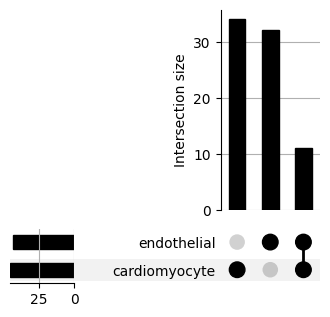

In [18]:
utils_analysis.cluster_grouping_upset_plot(mc, "cluster", "model", show=True, save_loc="tutorial_outputs/clusters_across_celltypes_upsetplot.png")

This shows how many motif *clusters* have elements that belong to the various celltypes or combinations of the various celltypes. In this particular case, 34 clusters have motifs only in cardiomyocytes, 32 clusters have motifs only in endothelial cells, and 11 clusters have motifs that were found in both cardiomyocytes and endothelial cells.

The `cluster_grouping_upset_plot()` function can also take any additional named arguments which are passed on as arguments to the UpSet constructor. For more information, please refer to the [UpSet constructor documentation](https://upsetplot.readthedocs.io/en/stable/api.html?highlight=upset#upsetplot.UpSet). In cases when you have many celltypes, the plot can become very wide. In that case, a useful argument to pass is the `min_subset_size` argument. For instance, setting `min_subset_size=15` removes all categories that have fewer than 15 elements.

/users/salil512/miniconda3/envs/motifcompendium-gpu/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/users/salil512/miniconda3/envs/motifcompendium-gpu/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on th

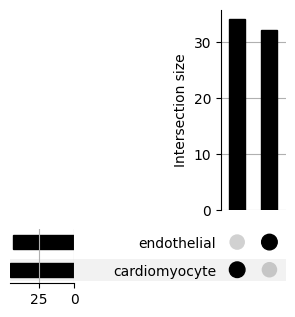

In [19]:
utils_analysis.cluster_grouping_upset_plot(mc, "cluster", "model", min_subset_size=15, show=True)

The `plot_unique_per_cluster()` creates a .html file where for each celltype, it displays the motif that is most unique to that celltype. You need to provide a MotifCompendium, the name of a column that has the groups you want to find unique motifs inside, and a path to save the file to.

In [20]:
utils_analysis.plot_unique_per_cluster(mc, "model", "tutorial_outputs/unique_per_celltype.html")

In the [most unique per celltype visualization](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/unique_per_celltype.html), each box represents a celltype and shows one motif with a similarity value associated with that motif. The similarity value is the highest similarity that the motif had with any motif in any other group. So, for instance, the most unique motif to cardiomyocytes had a similarity of 0.00493. This means that the highest similarity score that motif had with any non-cardiomyocyte motif was 0.00493.

This can be a approach to identifying the most unique motif per celltype. If you want to look at the underlying similarity scores yourself, you can make use of the `.get_similarity_slice()` method, which is covered in more detail in [Tutorial 2](2_motifcompendium_object.ipynb).

In [21]:
mc.get_similarity_slice(mc["model"] == "cardiomyocyte", mc["model"] != "cardiomyocyte", with_names=True)

,endothelial-pos.pattern_0,endothelial-pos.pattern_1,endothelial-pos.pattern_10,endothelial-pos.pattern_11,endothelial-pos.pattern_12,endothelial-pos.pattern_13,endothelial-pos.pattern_14,endothelial-pos.pattern_15,endothelial-pos.pattern_16,endothelial-pos.pattern_17,...,endothelial-pos.pattern_39,endothelial-pos.pattern_4,endothelial-pos.pattern_40,endothelial-pos.pattern_41,endothelial-pos.pattern_42,endothelial-pos.pattern_5,endothelial-pos.pattern_6,endothelial-pos.pattern_7,endothelial-pos.pattern_8,endothelial-pos.pattern_9
cardiomyocyte-pos.pattern_0,0.464071,0.997925,0.352505,0.564511,0.455523,0.323019,0.478032,0.472952,0.344467,0.486212,...,0.441887,0.366372,0.410421,0.349381,0.331646,0.287744,0.382783,0.350357,0.549569,0.468623
cardiomyocyte-pos.pattern_1,0.627148,0.497928,0.465772,0.564476,0.448402,0.283732,0.475982,0.476854,0.573628,0.452049,...,0.433153,0.415788,0.635967,0.424641,0.340721,0.399587,0.540950,0.377406,0.505956,0.342492
cardiomyocyte-pos.pattern_10,0.451371,0.590851,0.364954,0.405012,0.358733,0.458146,0.338321,0.381244,0.454093,0.367462,...,0.327768,0.497113,0.385818,0.497072,0.418676,0.625596,0.435134,0.584916,0.496769,0.382359
cardiomyocyte-pos.pattern_11,0.541545,0.360454,0.376347,0.475040,0.415899,0.509127,0.424525,0.452340,0.445831,0.463755,...,0.364307,0.448765,0.457448,0.420502,0.358931,0.452105,0.554770,0.460949,0.432536,0.300944
cardiomyocyte-pos.pattern_12,0.848302,0.441249,0.519615,0.715751,0.631528,0.513376,0.628750,0.684003,0.611156,0.663716,...,0.565650,0.313667,0.730905,0.330351,0.473038,0.318894,0.379443,0.706172,0.662640,0.640580
cardiomyocyte-pos.pattern_13,0.546412,0.469105,0.400749,0.495799,0.407899,0.441964,0.381591,0.447376,0.418094,0.396893,...,0.338969,0.463104,0.491489,0.480337,0.409110,0.594170,0.403014,0.679304,0.535822,0.338590
cardiomyocyte-pos.pattern_14,0.405624,0.382158,0.515914,0.369310,0.311162,0.293622,0.420562,0.356135,0.289564,0.453812,...,0.303002,0.510741,0.346026,0.529628,0.388965,0.308946,0.340724,0.459959,0.354079,0.315332
cardiomyocyte-pos.pattern_15,0.453795,0.464159,0.373276,0.377141,0.468263,0.378421,0.391476,0.536229,0.393995,0.453678,...,0.517227,0.331047,0.415036,0.332491,0.409525,0.301176,0.343481,0.490593,0.395770,0.998830
cardiomyocyte-pos.pattern_16,0.446272,0.466892,0.385115,0.377514,0.316639,0.355720,0.331757,0.371859,0.528023,0.329284,...,0.369480,0.447749,0.393713,0.436018,0.367510,0.647513,0.409212,0.743168,0.486416,0.308460
cardiomyocyte-pos.pattern_17,0.574449,0.356173,0.994859,0.512710,0.598479,0.418091,0.606472,0.545422,0.547178,0.605572,...,0.558040,0.379429,0.531514,0.383381,0.343745,0.292362,0.415504,0.359868,0.460322,0.374187


# Part 3 - Performing your own similarity calculations

The core computational engine behind the MotifCompendium package is the fast motif similarity calculation that can be parallelized, chunked, and GPU accelerated. You can access that similarity calculation engine yourself with the `compute_similarities()` function in the similarity submodule. The `compute_similarities()` function takes two arguments. First, it takes a list of non-negative, normalized motif stacks (refer to [Tutorial 2](2_motifcompendium_object.ipynb) for more information on this concept). The second argument is a list of tuples, where each tuple is a pair of indices, where the indices index into the list given as a first argument. The function returns a list of tuples of the same length as the second argument, in which each element of the resulting list is the result of the corresponding element in the second argument. Each result tuple consists of the similarity matrix, the alignment_rc matrix, and the alignment_h matrix corresponding to the calculation that was performed.

Let's consider a situation where we have 3 sets of motifs.

In [22]:
motifsA = np.random.rand(1000, 30, 8)
motifsA /= np.sum(motifsA, axis=(1, 2), keepdims=True)
motifsB = np.random.rand(2000, 30, 8)
motifsB /= np.sum(motifsB, axis=(1, 2), keepdims=True)
motifsC = np.random.rand(3000, 30, 8)
motifsC /= np.sum(motifsC, axis=(1, 2), keepdims=True)

And now, we are interested in performing 4 similarity calculations:

1) motifsA vs motifsA
2) motifsA vs motifsB
3) motifsB vs motifsC
4) motifsC vs motifsB

We would perform those calculations as follows:

In [23]:
results = utils_similarity.compute_similarities([motifsA, motifsB, motifsC], [(0, 0), (0, 1), (1, 2), (2, 1)])

computing similarities on GPU...: 100%|██████████| 15/15 [00:01<00:00,  9.35it/s]


Now, results will be a list of length 4 where each element `results[i]` is a tuple `(similarity, alignment_rc, alignment_h)`. The shape of those matrices will be `(N, M)` where `N` is the number of motifs in the first motif set involved in the calculation, and `M` is the number of motifs in the second motif set involved in the calculation. The values of the `similarity`, `alignment_rc`, and `alignment_h` matrices can be interpreted as they normally are.

In [24]:
similarity_0, alignment_rc_0, alignment_h_0 = results[0]
assert(similarity_0.shape == (1000, 1000) and alignment_rc_0.shape == (1000, 1000) and alignment_h_0.shape == (1000, 1000))
similarity_1, alignment_rc_1, alignment_h_1 = results[1]
assert(similarity_1.shape == (1000, 2000) and alignment_rc_1.shape == (1000, 2000) and alignment_h_1.shape == (1000, 2000))
similarity_2, alignment_rc_2, alignment_h_2 = results[2]
assert(similarity_2.shape == (2000, 3000) and alignment_rc_2.shape == (2000, 3000) and alignment_h_2.shape == (2000, 3000))
similarity_3, alignment_rc_3, alignment_h_3 = results[3]
assert(similarity_3.shape == (3000, 2000) and alignment_rc_3.shape == (3000, 2000) and alignment_h_3.shape == (3000, 2000))

This is how you can use the similarity calculation engine yourself!

# Part 4 - Available motif manipulation functionality

The motif submodule has many utilities for motif calculations and manipulations that may be useful for you. They will be listed here, but their usage will not be covered in full detail. Please read their descriptions for more information about them. The motif submodule, used in this code `utils_motif` can be imported as `MotifCompendium.utils.motif`.

- `reverse_complement()`: Takes the reverse complement of a motif or motif stack.
- `motif_4_to_8()`: Turns a 4-channel motif or motif stack into an 8-channel motif or motif stack.
- `motif_8_to_4_signed()`: Turns an 8-channel motif or motif stack into a signed 4-channel motif or motif stack.
- `motif_8_to_4_unsigned()`: Turns an 8-channel motif or motif stack into an unsigned 4-channel motif or motif stack, which is like the absolute value of `motif_8_to_4_signed()`.
- `align_motifs()`: Given a stack of motifs and information about how they should be aligned, returns an aligned version of the motif stack.
- `pad_motif()`: Pads a motif of shape `(L, K)` or a motif stack of shape `(N, L, K)`, pads with zeros to shape `(pad_to, K)` or `(N, pad_to, K)`, respectively.
- `resize_motif()`: Resizes a motif of shape `(L, K)` or a motif stack of shape `(N, L, K)`, pads with zeros to shape `(resize_to, K)` or `(N, resize_to, K)`, respectively, padding or trimming as needed.
- `trim_motif()`: Trims a motif or motif stack to cut off flank positions below a certain importance.
- `average_motifs()`: Given a motif stack and alignment information, aligns them and averages them.

These are just some of the useful functions in the motif submodule!

# Part 5 - Conclusion

This tutorial describes how to perform some common downstream tasks like exporting your motifs to FiNeMo and identifying motif-celltype incidence relationships. In addition, it shows how to make use of fast motif similarity calculations yourself, and highlights some useful functions for performing motif transformations and calculations.

Thank you so much for trying out MotifCompendium!